In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential # Takes the layer one by 1
from tensorflow.keras.layers import Dense # Creates a fully connected layers

In [47]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Sample Dataset
texts = [
    # Positive
    "I love this movie",
    "Excellent story",
    "I love chicken",
    "This is amazing and wonderful",
    "Best experience ever",
    "Absolutely fantastic work",

    # Negative
    "I hate this movie",
    "Mcdonalds is bad",
    "Terrible service and rude staff",
    "This is the worst thing ever",
    "Awful experience never again",
    "I really dislike this product",

    # Neutral
    "Long live the King",
    "Contrary to popular belief Lorem Ipsum is not simply random",
    "Strike while the iron is hot or whatever",
    "The meeting is scheduled for Monday",
    "The store opens at nine in the morning",
    "He drove to the office after lunch",
    "The report contains five sections",
    "She moved to Berlin last year",
]

# Create labels
# 1 is neutral (Previously positive)
# 0 is negative
# 2 is positive 

labels = np.array([2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1])

# One-hot encode them
from tensorflow.keras.utils import to_categorical
labels_onehot = to_categorical(labels, num_classes=3)

# Create a tf-idf vectorizer
vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform the texts into TF-IDF features
tfidf_matrix = vectorizer.fit_transform(texts)

# See the results
print("Feature names:", vectorizer.get_feature_names_out())
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("TF-IDF matrix:\n", tfidf_matrix.toarray())

Feature names: ['absolutely' 'amazing' 'awful' 'bad' 'belief' 'berlin' 'best' 'chicken'
 'contains' 'contrary' 'dislike' 'drove' 'excellent' 'experience'
 'fantastic' 'hate' 'hot' 'ipsum' 'iron' 'king' 'live' 'long' 'lorem'
 'love' 'lunch' 'mcdonalds' 'meeting' 'monday' 'morning' 'moved' 'movie'
 'office' 'opens' 'popular' 'product' 'random' 'really' 'report' 'rude'
 'scheduled' 'sections' 'service' 'simply' 'staff' 'store' 'story'
 'strike' 'terrible' 'thing' 'wonderful' 'work' 'worst' 'year']
TF-IDF matrix shape: (20, 53)
TF-IDF matrix:
 [[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.57735027]]


In [49]:
model = Sequential()
model.add(Dense(7, activation='relu', input_shape=(tfidf_matrix.shape[1],)))
# output layer
model.add(Dense(3, activation='softmax'))

# changed from binary_crossentropy to categorical as we are using 3 labels now
model.compile(
    optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']
)

In [50]:
history = model.fit(tfidf_matrix, labels_onehot, epochs=250, verbose=0)

In [51]:
new_text = ["it is popular so, why not?"]
new_vector = vectorizer.transform(new_text).toarray()
prediction = model.predict(new_vector)

class_names = ["Negative", "Neutral", "Positive"]
predicted_class = np.argmax(prediction[0])

print("Probabilities:", prediction[0])
print("Prediction:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Probabilities: [0.3241616  0.35689807 0.3189403 ]
Prediction: Neutral


In [43]:
!pip install matplotlib

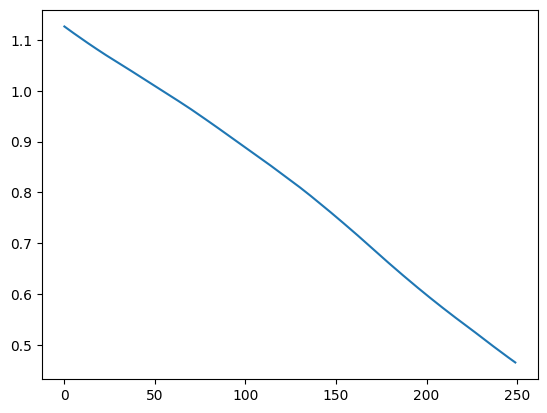

In [52]:
import matplotlib.pyplot as plt

# Training loss
plt.plot(history.history['loss'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


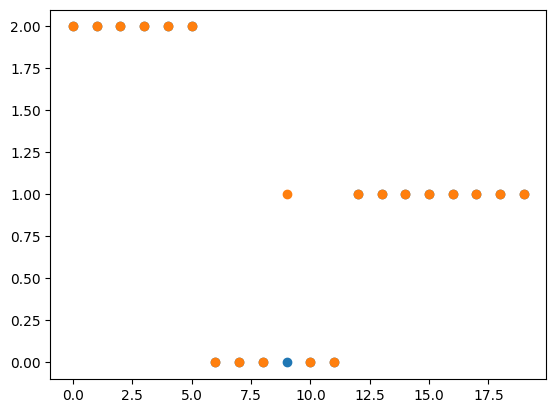

In [59]:
predictions = np.argmax(model.predict(tfidf_matrix), axis=1)
plt.scatter(range(len(labels)), labels)
plt.scatter(range(len(predictions)), predictions)
plt.show()